# Basic Recommendation System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
train_customers = pd.read_csv("Train/train_customers.csv")
train_locations = pd.read_csv("Train/train_locations.csv")
orders = pd.read_csv("Train/orders.csv")
vendors = pd.read_csv("Train/vendors.csv")

test_customers = pd.read_csv("Test/test_customers.csv")
test_locations = pd.read_csv("Test/test_locations.csv")


C:\Users\kottu\AppData\Local\Temp\ipykernel_13920\1013596823.py:3: DtypeWarning: Columns (15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv("Train/orders.csv")


- ## Exploring Data

In [3]:

print(orders.columns)



Index(['order_id', 'customer_id', 'item_count', 'grand_total', 'payment_mode',
       'promo_code', 'vendor_discount_amount',
       'promo_code_discount_percentage', 'is_favorite', 'is_rated',
       'vendor_rating', 'driver_rating', 'deliverydistance', 'preparationtime',
       'delivery_time', 'order_accepted_time', 'driver_accepted_time',
       'ready_for_pickup_time', 'picked_up_time', 'delivered_time',
       'delivery_date', 'vendor_id', 'created_at', 'LOCATION_NUMBER',
       'LOCATION_TYPE', 'CID X LOC_NUM X VENDOR'],
      dtype='object')


In [4]:
print(train_locations.columns)


Index(['customer_id', 'location_number', 'location_type', 'latitude',
       'longitude'],
      dtype='object')


In [5]:
print(vendors.columns)


Index(['id', 'authentication_id', 'latitude', 'longitude',
       'vendor_category_en', 'vendor_category_id', 'delivery_charge',
       'serving_distance', 'is_open', 'OpeningTime', 'OpeningTime2',
       'prepration_time', 'commission', 'is_haked_delivering',
       'discount_percentage', 'status', 'verified', 'rank', 'language',
       'vendor_rating', 'sunday_from_time1', 'sunday_to_time1',
       'sunday_from_time2', 'sunday_to_time2', 'monday_from_time1',
       'monday_to_time1', 'monday_from_time2', 'monday_to_time2',
       'tuesday_from_time1', 'tuesday_to_time1', 'tuesday_from_time2',
       'tuesday_to_time2', 'wednesday_from_time1', 'wednesday_to_time1',
       'wednesday_from_time2', 'wednesday_to_time2', 'thursday_from_time1',
       'thursday_to_time1', 'thursday_from_time2', 'thursday_to_time2',
       'friday_from_time1', 'friday_to_time1', 'friday_from_time2',
       'friday_to_time2', 'saturday_from_time1', 'saturday_to_time1',
       'saturday_from_time2', 'saturday

In [6]:
print(train_customers.columns)


Index(['customer_id', 'gender', 'dob', 'status', 'verified', 'language',
       'created_at', 'updated_at'],
      dtype='object')


In [7]:
print("Train customers shape:", train_customers.shape)
print("Train locations shape:", train_locations.shape)
print("Orders shape:", orders.shape)
print("Vendors shape:", vendors.shape)
print("Test customers shape:", test_customers.shape)
print("Test locations shape:", test_locations.shape)



Train customers shape: (34674, 8)
Train locations shape: (59503, 5)
Orders shape: (135303, 26)
Vendors shape: (100, 59)
Test customers shape: (9768, 8)
Test locations shape: (16720, 5)


In [8]:
orders_loc = orders.merge(
    train_locations,
    left_on=["customer_id", "LOCATION_NUMBER"],
    right_on=["customer_id", "location_number"],
    how="left",
)

orders_full = orders_loc.merge(vendors, left_on="vendor_id", right_on="id", how="left")
orders_full.head()


,order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,...,open_close_flags,vendor_tag,vendor_tag_name,one_click_vendor,country_id,city_id,created_at_y,updated_at,device_type,display_orders
0,163923.0,KL09J9N,6.0,10.1,1,NaN,0.0,NaN,NaN,No,...,1,"5,30,48,23","Burgers,Fries,Kids meal,Shawarma",Y,1,1,9/16/2023 19:37,4/7/2025 21:08,3,1
1,163924.0,H5LGGFX,3.0,8.4,1,NaN,0.0,NaN,NaN,No,...,1,"15,34,4,28,27,24,8","Pizzas,Italian,Breakfast,Soups,Pasta,Salads,De...",Y,1,1,8/26/2023 21:47,3/31/2025 22:16,3,1
2,163925.0,CYLZB6T,4.0,15.0,1,NaN,0.0,NaN,NaN,No,...,1,"2,4,5,8,91,22,12,24,16,23","Arabic,Breakfast,Burgers,Desserts,Free Deliver...",Y,1,1,1/30/2023 14:42,4/7/2025 15:12,3,1
3,163929.0,4YKUKYN,7.0,27.2,1,NaN,0.0,NaN,NaN,No,...,1,"31,8,10,33,67,21","Biryani,Desserts,Indian,Rice,Thali,Vegetarian",Y,1,1,1/19/2024 14:01,4/7/2025 20:03,3,1
4,163930.0,WDNU30K,1.0,6.5,1,NaN,0.0,NaN,NaN,No,...,1,"1,5,48,16","American,Burgers,Kids meal,Sandwiches",Y,1,1,1/28/2024 20:37,4/3/2025 22:36,3,1


In [9]:
print("=== ORIGINAL DATA IMBALANCE ANALYSIS ===\n")

positive_count = len(orders_full)
print(f"Positive examples (actual orders): {positive_count}")

total_combinations = len(train_locations) * len(vendors)
print(f"Total possible combinations (customers × locations × vendors): {total_combinations}")

imbalance_ratio = positive_count / total_combinations
print(f"Percentage of combinations with orders: {imbalance_ratio * 100:.2f}%")
print(f"Percentage without orders: {(1 - imbalance_ratio) * 100:.2f}%")


=== ORIGINAL DATA IMBALANCE ANALYSIS ===

Positive examples (actual orders): 135303
Total possible combinations (customers × locations × vendors): 5950300
Percentage of combinations with orders: 2.27%
Percentage without orders: 97.73%


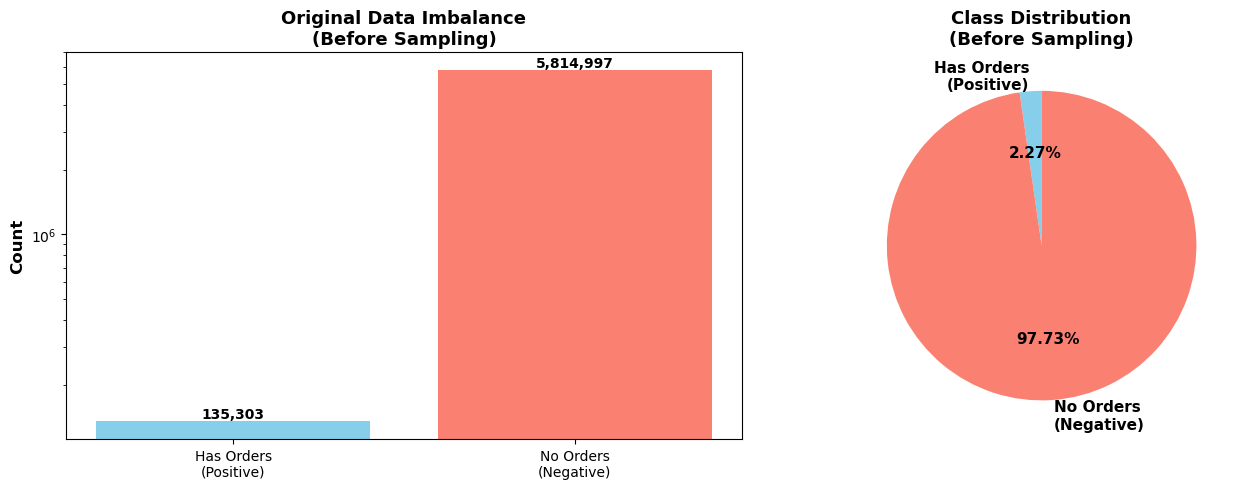


Imbalance Ratio: 1:43.0
(For every 1 positive example, there are ~43.0 negative examples)



In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Has Orders\n(Positive)', 'No Orders\n(Negative)']
counts = [positive_count, total_combinations - positive_count]
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(categories, counts, color=['skyblue', 'salmon'], linewidth=1.5)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Original Data Imbalance\n(Before Sampling)', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')
for i, v in enumerate(counts):
    axes[0].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts, labels=categories, autopct='%1.2f%%', colors=['skyblue', 'salmon'], 
            startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution\n(Before Sampling)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nImbalance Ratio: 1:{(total_combinations - positive_count) / positive_count:.1f}")
print("(For every 1 positive example, there are ~{:.1f} negative examples)\n".format(
    (total_combinations - positive_count) / positive_count))


- ## Generating minority class samples

In [ ]:
positive = orders_full[["customer_id", "location_number", "vendor_id"]].copy()
positive["target"] = 1

all_combinations = train_locations.merge(vendors[["id"]], how="cross")
all_combinations = all_combinations.rename(columns={"id": "vendor_id"})
all_combinations = all_combinations.merge(
    positive[["customer_id", "location_number", "vendor_id"]],
    on=["customer_id", "location_number", "vendor_id"],
    how="left",
    indicator=True,
)

all_combinations.head()


,customer_id,location_number,location_type,latitude,longitude,vendor_id,_merge
0,02SFNJH,0,NaN,1.682392,-78.789737,4,left_only
1,02SFNJH,0,NaN,1.682392,-78.789737,13,left_only
2,02SFNJH,0,NaN,1.682392,-78.789737,20,left_only
3,02SFNJH,0,NaN,1.682392,-78.789737,23,left_only
4,02SFNJH,0,NaN,1.682392,-78.789737,28,left_only


In [12]:
negative = all_combinations[all_combinations["_merge"] == "left_only"][
    ["customer_id", "location_number", "vendor_id"]
].sample(n=len(positive), random_state=42)
negative["target"] = 0

train_data = pd.concat([positive, negative], ignore_index=True)

print("Train data shape:", train_data.shape)
print("Positive:", len(positive))
print("Negative:", len(negative))


Train data shape: (270606, 4)
Positive: 135303
Negative: 135303


In [13]:
positive.head()


,customer_id,location_number,vendor_id,target
0,KL09J9N,0,84,1
1,H5LGGFX,0,78,1
2,CYLZB6T,0,4,1
3,4YKUKYN,0,157,1
4,WDNU30K,0,160,1


In [14]:
negative.head()


,customer_id,location_number,vendor_id,target
2081612,WHMKIEJ,0,28,0
629717,14BNHZB,0,75,0
4463988,CANGTQ6,0,195,0
4147582,LGCSX76,3,192,0
1864300,BQ34XYB,0,681,0


C:\Users\kottu\AppData\Local\Temp\ipykernel_13920\1582780652.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=train_data, palette=['salmon', 'skyblue'], ax=axes[0])
C:\Users\kottu\AppData\Local\Temp\ipykernel_13920\1582780652.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'])


<Figure size 1000x600 with 0 Axes>

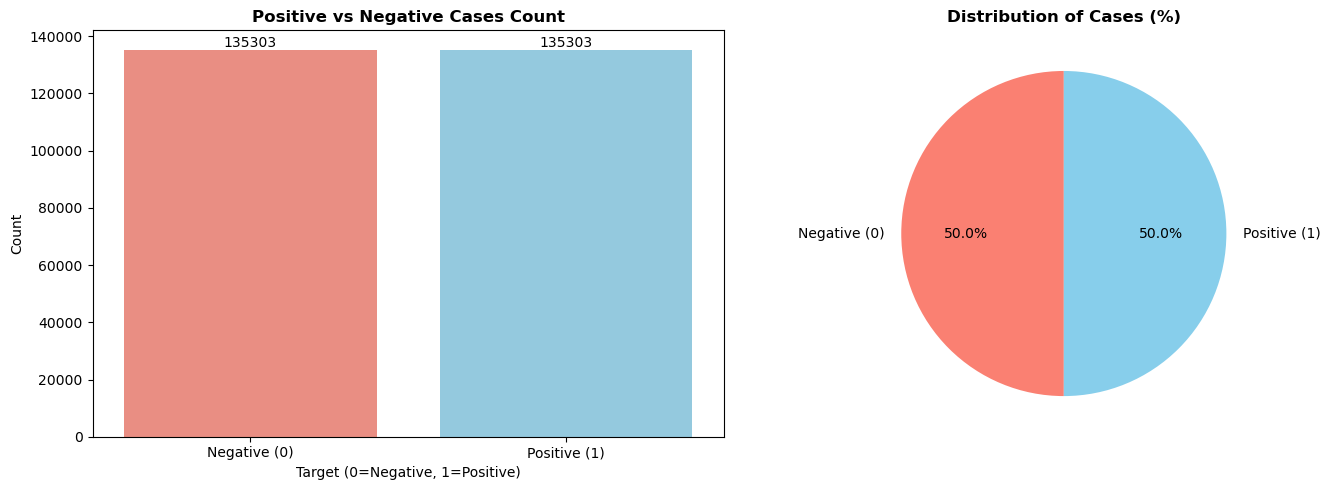


Data Imbalance Summary:
Total samples: 270606
Positive cases (1): 135303
Negative cases (0): 135303
Ratio (Positive/Negative): 1.00


In [ ]:
plt.figure(figsize=(10, 6))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='target', data=train_data, palette=['salmon', 'skyblue'], ax=axes[0])
axes[0].set_title('Positive vs Negative Cases Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target (0=Negative, 1=Positive)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'])

for container in axes[0].containers:
    axes[0].bar_label(container)


target_counts = train_data['target'].value_counts()
colors = ['salmon', 'skyblue']
axes[1].pie(target_counts.values, labels=['Negative (0)', 'Positive (1)'], 
            autopct='%1.1f%%', colors=['salmon', 'skyblue'], startangle=90)
axes[1].set_title('Distribution of Cases (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nData Imbalance Summary:")
print(f"Total samples: {len(train_data)}")
print(f"Positive cases (1): {(train_data['target'] == 1).sum()}")
print(f"Negative cases (0): {(train_data['target'] == 0).sum()}")
print(f"Ratio (Positive/Negative): {(train_data['target'] == 1).sum() / (train_data['target'] == 0).sum():.2f}")


In [27]:
print("Target distribution in train_data:")
print(train_data["target"].value_counts())



Target distribution in train_data:
target
0    135700
1    135502
Name: count, dtype: int64


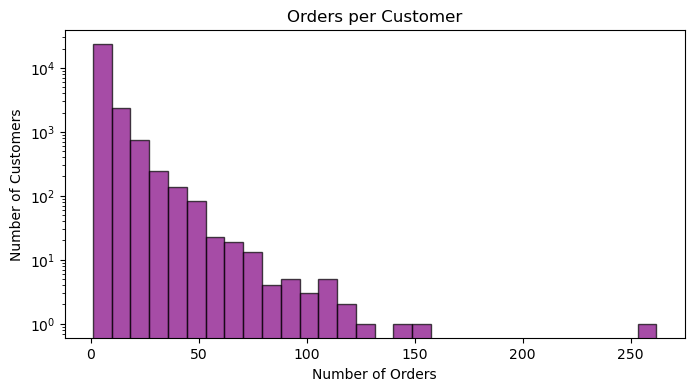

In [17]:

order_counts = orders["customer_id"].value_counts()
plt.figure(figsize=(8, 4))
plt.hist(order_counts, bins=30, color="purple", edgecolor="black", alpha=0.7)
plt.title("Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.yscale("log")
plt.show()


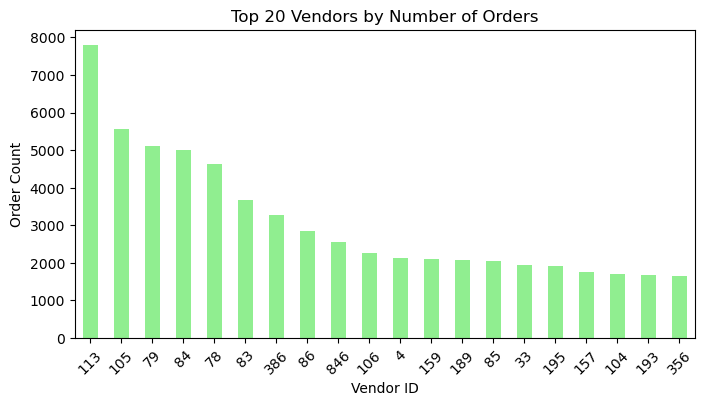

In [18]:

vendor_order_counts = orders["vendor_id"].value_counts()
plt.figure(figsize=(8, 4))
vendor_order_counts.head(20).plot(kind="bar", color="lightgreen")
plt.title("Top 20 Vendors by Number of Orders")
plt.xlabel("Vendor ID")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.show()


In [19]:

print("\nOrders per customer summary:")
print(order_counts.describe())
print("\nTop vendors by order count:")
print(vendor_order_counts.head(10))



Orders per customer summary:
count    27445.000000
mean         4.929969
std          7.621525
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        262.000000
Name: count, dtype: float64

Top vendors by order count:
vendor_id
113    7807
105    5562
79     5117
84     5001
78     4643
83     3684
386    3280
86     2837
846    2559
106    2263
Name: count, dtype: int64


- ## Data preparation

In [21]:
train_data = train_data.merge(train_customers, on="customer_id", how="left")
train_data = train_data.merge(
    train_locations, on=["customer_id", "location_number"], how="left"
)
train_data = train_data.merge(
    vendors, left_on="vendor_id", right_on="id", how="left", suffixes=("", "_vendor")
)


In [ ]:
train_data.columns


Index(['customer_id', 'location_number', 'vendor_id', 'target', 'gender',
       'dob', 'status', 'verified', 'language', 'created_at', 'updated_at',
       'location_type', 'latitude', 'longitude', 'id', 'authentication_id',
       'latitude_vendor', 'longitude_vendor', 'vendor_category_en',
       'vendor_category_id', 'delivery_charge', 'serving_distance', 'is_open',
       'OpeningTime', 'OpeningTime2', 'prepration_time', 'commission',
       'is_haked_delivering', 'discount_percentage', 'status_vendor',
       'verified_vendor', 'rank', 'language_vendor', 'vendor_rating',
       'sunday_from_time1', 'sunday_to_time1', 'sunday_from_time2',
       'sunday_to_time2', 'monday_from_time1', 'monday_to_time1',
       'monday_from_time2', 'monday_to_time2', 'tuesday_from_time1',
       'tuesday_to_time1', 'tuesday_from_time2', 'tuesday_to_time2',
       'wednesday_from_time1', 'wednesday_to_time1', 'wednesday_from_time2',
       'wednesday_to_time2', 'thursday_from_time1', 'thursday_to_ti

In [28]:
from math import radians, cos, sin, asin, sqrt


def haversine(lat1, lon1, lat2, lon2):
    R = 6371  
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = (
        sin(dlat / 2) ** 2
        + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    )
    c = 2 * asin(sqrt(a))
    return R * c


In [29]:
train_data["distance"] = train_data.apply(
    lambda row: haversine(
        row["latitude"],
        row["longitude"],
        row["latitude_vendor"],
        row["longitude_vendor"],
    ),
    axis=1,
)

features = [
    "gender",
    "status",
    "verified",
    "location_type",
    "latitude",
    "longitude",
    "vendor_category_id",
    "delivery_charge",
    "serving_distance",
    "vendor_rating",
    "distance",
]
X = train_data[features]
y = train_data["target"]

X = pd.get_dummies(X, columns=["gender", "location_type"], drop_first=True)

print("Features shape:", X.shape)


Features shape: (271202, 20)


In [30]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


Accuracy: 0.8483988127062554
              precision    recall  f1-score   support

           0       0.87      0.82      0.84     27089
           1       0.83      0.87      0.85     27152

    accuracy                           0.85     54241
   macro avg       0.85      0.85      0.85     54241
weighted avg       0.85      0.85      0.85     54241



- ## Prediction on test data

In [31]:
test_combinations = test_locations.merge(test_customers, on="customer_id", how="left")
test_combinations = test_combinations.merge(vendors[["id"]], how="cross")
test_combinations = test_combinations.rename(columns={"id": "vendor_id"})
test_combinations = test_combinations.merge(
    vendors, left_on="vendor_id", right_on="id", how="left", suffixes=("", "_vendor")
)

print("Columns after merge:", test_combinations.columns.tolist())


Columns after merge: ['customer_id', 'location_number', 'location_type', 'latitude', 'longitude', 'gender', 'dob', 'status', 'verified', 'language', 'created_at', 'updated_at', 'vendor_id', 'id', 'authentication_id', 'latitude_vendor', 'longitude_vendor', 'vendor_category_en', 'vendor_category_id', 'delivery_charge', 'serving_distance', 'is_open', 'OpeningTime', 'OpeningTime2', 'prepration_time', 'commission', 'is_haked_delivering', 'discount_percentage', 'status_vendor', 'verified_vendor', 'rank', 'language_vendor', 'vendor_rating', 'sunday_from_time1', 'sunday_to_time1', 'sunday_from_time2', 'sunday_to_time2', 'monday_from_time1', 'monday_to_time1', 'monday_from_time2', 'monday_to_time2', 'tuesday_from_time1', 'tuesday_to_time1', 'tuesday_from_time2', 'tuesday_to_time2', 'wednesday_from_time1', 'wednesday_to_time1', 'wednesday_from_time2', 'wednesday_to_time2', 'thursday_from_time1', 'thursday_to_time1', 'thursday_from_time2', 'thursday_to_time2', 'friday_from_time1', 'friday_to_time

In [ ]:

test_combinations["distance"] = test_combinations.apply(
    lambda row: haversine(
        row["latitude"],
        row["longitude"],
        row["latitude_vendor"],
        row["longitude_vendor"],
    ),
    axis=1,
)
test_combinations.columns


Index(['customer_id', 'location_number', 'location_type', 'latitude',
       'longitude', 'gender', 'dob', 'status', 'verified', 'language',
       'created_at', 'updated_at', 'vendor_id', 'id', 'authentication_id',
       'latitude_vendor', 'longitude_vendor', 'vendor_category_en',
       'vendor_category_id', 'delivery_charge', 'serving_distance', 'is_open',
       'OpeningTime', 'OpeningTime2', 'prepration_time', 'commission',
       'is_haked_delivering', 'discount_percentage', 'status_vendor',
       'verified_vendor', 'rank', 'language_vendor', 'vendor_rating',
       'sunday_from_time1', 'sunday_to_time1', 'sunday_from_time2',
       'sunday_to_time2', 'monday_from_time1', 'monday_to_time1',
       'monday_from_time2', 'monday_to_time2', 'tuesday_from_time1',
       'tuesday_to_time1', 'tuesday_from_time2', 'tuesday_to_time2',
       'wednesday_from_time1', 'wednesday_to_time1', 'wednesday_from_time2',
       'wednesday_to_time2', 'thursday_from_time1', 'thursday_to_time1',
    

In [33]:
X_test = test_combinations[features]
X_test = pd.get_dummies(X_test, columns=["gender", "location_type"], drop_first=True)


missing_cols = set(X.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
X_test = X_test[X.columns]


test_combinations["target"] = model.predict_proba(X_test)[:, 1]  

submission = test_combinations[["customer_id", "location_number", "vendor_id", "target"]]

submission["CID X LOC_NUM X VENDOR"] = (
    submission["customer_id"]
    + " X "
    + submission["location_number"].astype(str)
    + " X "
    + submission["vendor_id"].astype(str)
)
submission = submission[["CID X LOC_NUM X VENDOR", "target"]]

submission.to_csv("submission.csv", index=False)
print("Submission saved.")


C:\Users\kottu\AppData\Local\Temp\ipykernel_13920\654133001.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission["CID X LOC_NUM X VENDOR"] = (


Submission saved.
